# 01 — Data Exploration & Cleaning
## MietOptimal / RentSignal

**Input:** `data/raw/listings/immo_data.csv` (Kaggle ImmoScout24, 268k listings Germany-wide)  
**Output:** `data/processed/listings_clean.parquet` (cleaned Berlin rentals, model-ready)

### Pipeline
1. Load raw data, filter to Berlin
2. Inspect distributions, missing values, outliers
3. Clean: remove duplicates, fix types, handle outliers
4. Feature engineering: extract district, rent/m², building era brackets
5. Handle missing values
6. Export clean parquet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

c:\Users\danny\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\danny\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Load & Filter to Berlin

In [2]:
raw = pd.read_csv("../data/raw/listings/immo_data.csv", low_memory=False)
print(f"Full dataset: {len(raw):,} rows, {len(raw.columns)} columns")

berlin = raw[raw["regio1"] == "Berlin"].copy()
print(f"Berlin subset: {len(berlin):,} rows")

# Snapshot dates
print(f"\nData snapshots:\n{berlin['date'].value_counts().to_string()}")

Full dataset: 268,850 rows, 49 columns
Berlin subset: 10,406 rows

Data snapshots:
date
May19    2869
Feb20    2787
Oct19    2755
Sep18    1995


## 2. Select & Inspect Key Features

In [3]:
# Columns we care about for the rent prediction model
KEEP_COLS = [
    # Target
    "baseRent", "totalRent", "serviceCharge",
    # Numeric
    "livingSpace", "noRooms", "yearConstructed", "floor", "numberOfFloors",
    "thermalChar",
    # Binary
    "balcony", "hasKitchen", "lift", "cellar", "garden", "newlyConst",
    # Categorical
    "condition", "interiorQual", "typeOfFlat", "heatingType",
    "energyEfficiencyClass",
    # Location
    "regio3", "geo_plz",
    # Meta
    "scoutId", "date",
]

df = berlin[KEEP_COLS].copy()
print(f"Working dataset: {df.shape}")

# Missing values summary
missing = df.isnull().mean().mul(100).round(1)
print("\n--- Missing values (%) ---")
print(missing[missing > 0].sort_values(ascending=False).to_string())

Working dataset: (10406, 24)

--- Missing values (%) ---
energyEfficiencyClass    66.5
interiorQual             40.4
thermalChar              31.5
numberOfFloors           30.0
condition                21.8
heatingType              14.1
yearConstructed          13.7
floor                    10.6
typeOfFlat                7.7
totalRent                 6.4
serviceCharge             2.3


## 3. EDA — Distributions & Outliers

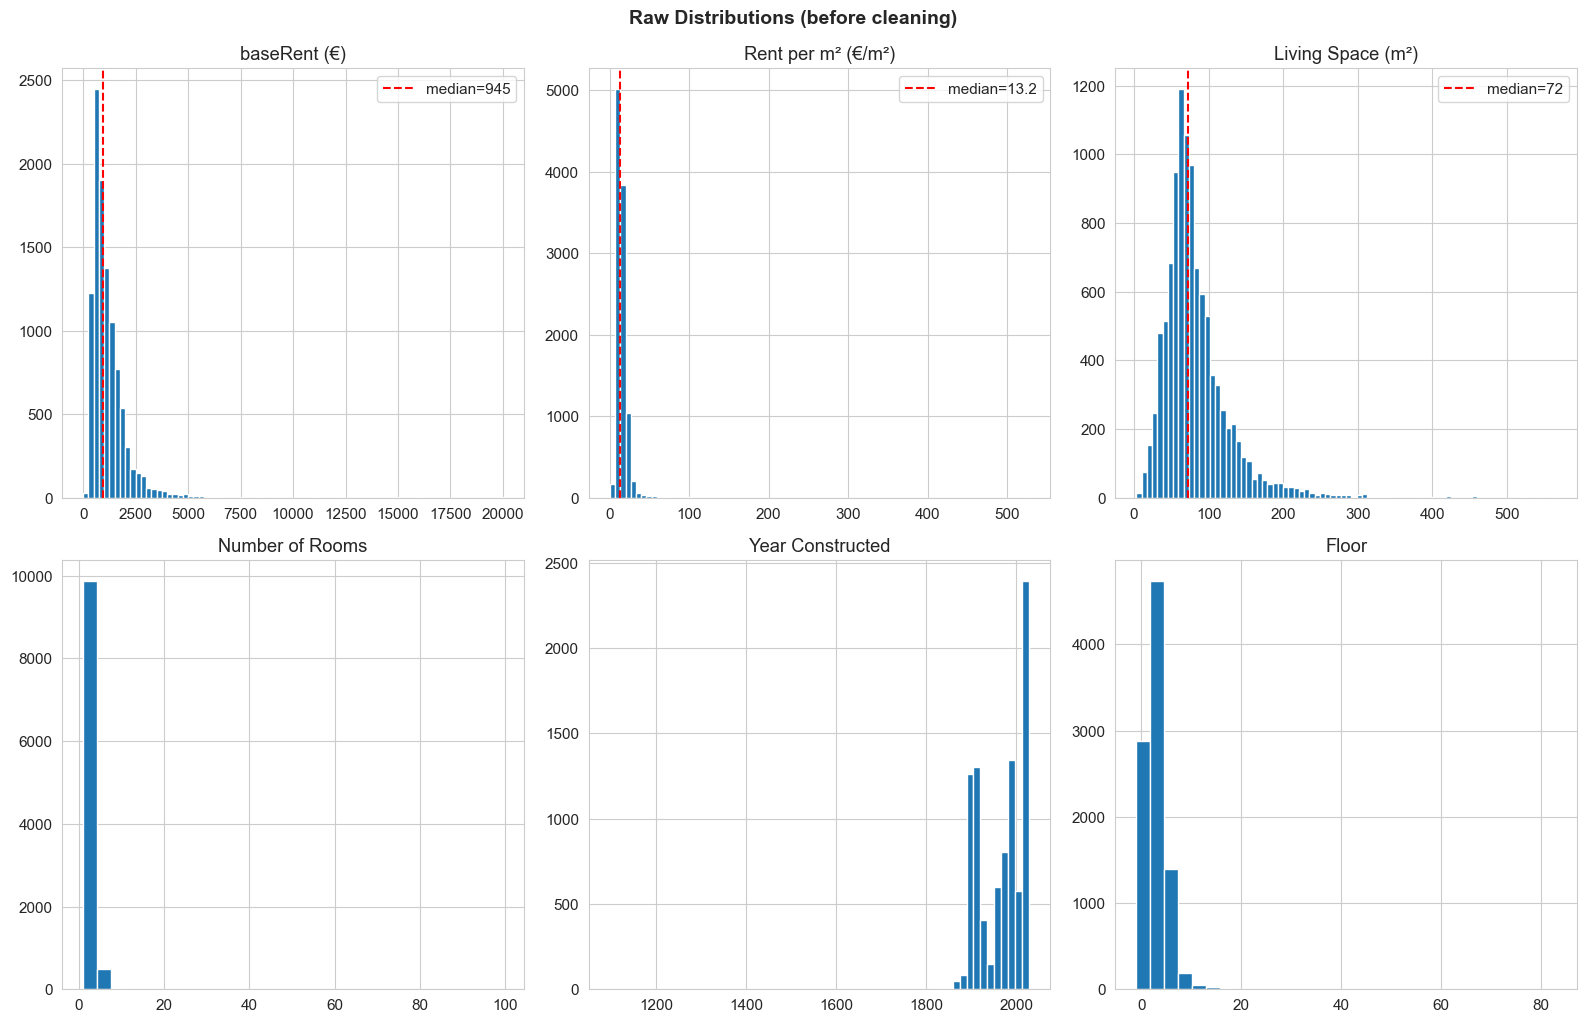

In [4]:
# Derived: rent per sqm (our actual prediction target)
df["rent_sqm"] = df["baseRent"] / df["livingSpace"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].hist(df["baseRent"], bins=80, edgecolor="white")
axes[0, 0].set_title("baseRent (€)")
axes[0, 0].axvline(df["baseRent"].median(), color="red", ls="--", label=f'median={df["baseRent"].median():.0f}')
axes[0, 0].legend()

axes[0, 1].hist(df["rent_sqm"].dropna(), bins=80, edgecolor="white")
axes[0, 1].set_title("Rent per m² (€/m²)")
axes[0, 1].axvline(df["rent_sqm"].median(), color="red", ls="--", label=f'median={df["rent_sqm"].median():.1f}')
axes[0, 1].legend()

axes[0, 2].hist(df["livingSpace"], bins=80, edgecolor="white")
axes[0, 2].set_title("Living Space (m²)")
axes[0, 2].axvline(df["livingSpace"].median(), color="red", ls="--", label=f'median={df["livingSpace"].median():.0f}')
axes[0, 2].legend()

axes[1, 0].hist(df["noRooms"].dropna(), bins=30, edgecolor="white")
axes[1, 0].set_title("Number of Rooms")

axes[1, 1].hist(df["yearConstructed"].dropna(), bins=60, edgecolor="white")
axes[1, 1].set_title("Year Constructed")

axes[1, 2].hist(df["floor"].dropna(), bins=30, edgecolor="white")
axes[1, 2].set_title("Floor")

plt.tight_layout()
plt.suptitle("Raw Distributions (before cleaning)", y=1.02, fontsize=14, fontweight="bold")
plt.show()

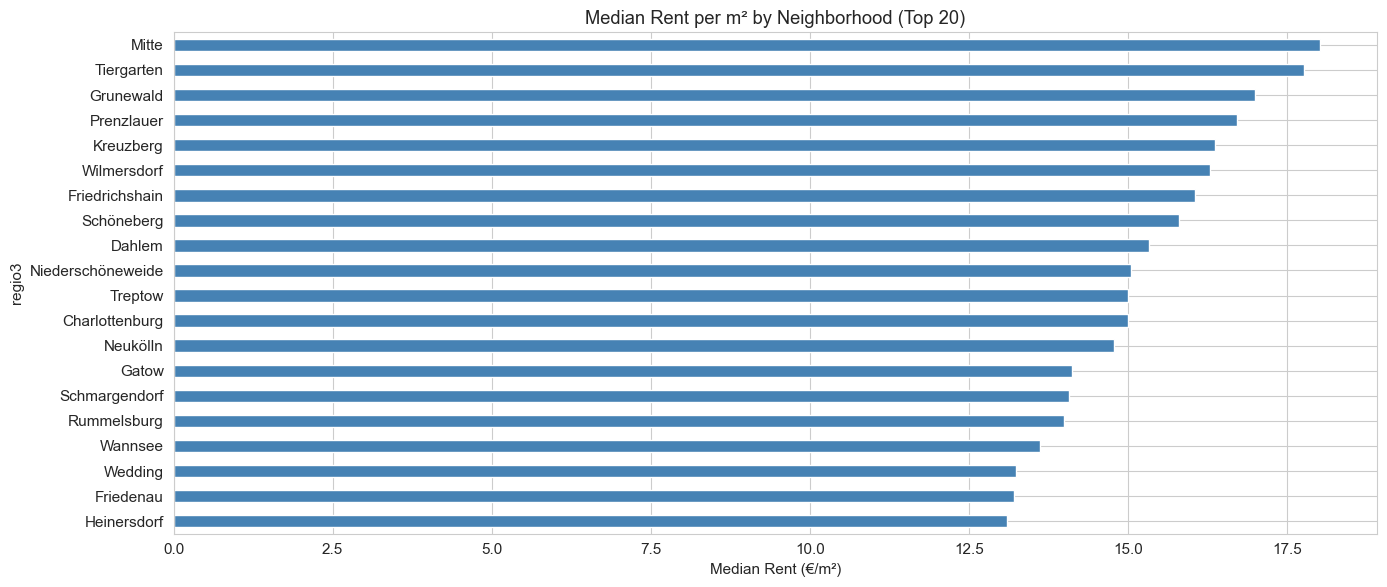


Cheapest: Waidmannslust (7.2 €/m²)
Most expensive: Mitte (18.0 €/m²)


In [5]:
# Rent per sqm by district (top 15)
district = df["regio3"].str.split("_", n=1).str[0]
rent_by_district = df.groupby(district)["rent_sqm"].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
rent_by_district.head(20).plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Median Rent (€/m²)")
ax.set_title("Median Rent per m² by Neighborhood (Top 20)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nCheapest: {rent_by_district.index[-1]} ({rent_by_district.iloc[-1]:.1f} €/m²)")
print(f"Most expensive: {rent_by_district.index[0]} ({rent_by_district.iloc[0]:.1f} €/m²)")

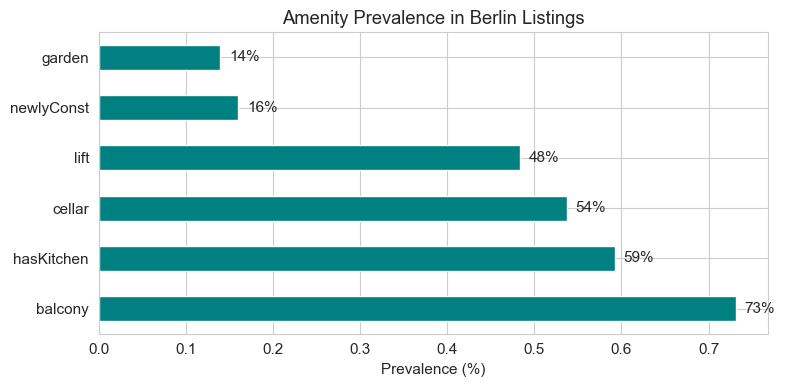

In [6]:
# Amenity prevalence
amenities = ["balcony", "hasKitchen", "lift", "cellar", "garden", "newlyConst"]
amenity_rates = df[amenities].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
amenity_rates.plot.barh(ax=ax, color="teal")
ax.set_xlabel("Prevalence (%)")
ax.set_title("Amenity Prevalence in Berlin Listings")
for i, v in enumerate(amenity_rates):
    ax.text(v + 0.01, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()

## 4. Cleaning

Rules:
- Drop rows with `baseRent <= 0` or `livingSpace < 10` (invalid)
- Drop extreme outliers: `rent_sqm > 40` (luxury/commercial misclassified), `rent_sqm < 3` (likely errors)
- Drop `livingSpace > 300` (commercial), `noRooms > 10` (commercial/error)
- Drop `floor > 30` (data entry errors — Berlin max ~27 floors)
- Cap `yearConstructed` to [1850, 2025] range
- Extract clean district name from `regio3`
- Extract Bezirk (borough) from `regio3`

In [7]:
n_before = len(df)

# Basic validity filters
df = df[df["baseRent"] > 0].copy()
df = df[df["livingSpace"] >= 10]
df = df[df["livingSpace"] <= 300]
df = df[df["noRooms"] <= 10]

# Recompute rent_sqm after basic filters
df["rent_sqm"] = df["baseRent"] / df["livingSpace"]

# Rent per sqm outliers
df = df[(df["rent_sqm"] >= 3) & (df["rent_sqm"] <= 40)]

# Floor outliers
df = df[(df["floor"].isna()) | (df["floor"] <= 30)]

# Year constructed: cap to valid range
df.loc[df["yearConstructed"] < 1850, "yearConstructed"] = np.nan
df.loc[df["yearConstructed"] > 2025, "yearConstructed"] = np.nan

n_after = len(df)
print(f"Rows removed: {n_before - n_after:,} ({(n_before - n_after) / n_before:.1%})")
print(f"Rows remaining: {n_after:,}")

Rows removed: 131 (1.3%)
Rows remaining: 10,275


## 5. Feature Engineering

In [8]:
# --- Extract district (Ortsteil) and borough (Bezirk) from regio3 ---
# regio3 format: "Kreuzberg_Kreuzberg" → neighborhood_borough
# or "Prenzlauer_Berg_Prenzlauer_Berg" → multi-word names

# The part after the LAST underscore-group that matches the second half is the Bezirk
# Simpler: split on "_" and take the pattern
parts = df["regio3"].str.rsplit("_", n=1)
df["bezirk"] = parts.str[1]  # borough (Bezirk)

# For neighborhood, we need to map from regio3
# The format is "Ortsteil_Bezirk" — extract everything before the last occurrence of Bezirk
df["neighborhood"] = df.apply(
    lambda r: r["regio3"].replace("_" + r["bezirk"], "", 1) if pd.notna(r["regio3"]) else np.nan,
    axis=1,
)
# Clean up underscores in names
df["neighborhood"] = df["neighborhood"].str.replace("_", " ")
df["bezirk"] = df["bezirk"].str.replace("_", " ")

print(f"Unique neighborhoods: {df['neighborhood'].nunique()}")
print(f"Unique Bezirke: {df['bezirk'].nunique()}")
print(f"\nBezirk distribution:\n{df['bezirk'].value_counts().to_string()}")

Unique neighborhoods: 79
Unique Bezirke: 23

Bezirk distribution:
bezirk
Mitte               768
Tiergarten          713
Charlottenburg      689
Köpenick            645
Spandau             612
Friedrichshain      551
Wilmersdorf         548
Reinickendorf       517
Neukölln            512
Berg                472
Steglitz            422
Treptow             421
Wedding             397
Pankow              386
Lichtenberg         358
Hellersdorf         331
Tempelhof           330
Schöneberg          324
Kreuzberg           323
Weißensee           282
Marzahn             260
Zehlendorf          216
Hohenschönhausen    198


In [9]:
# --- Building era brackets (Mietspiegel-aligned) ---
def building_era(year):
    if pd.isna(year):
        return "unknown"
    year = int(year)
    if year < 1919:
        return "pre_1918"       # Altbau
    elif year < 1950:
        return "1919_1949"      # Interwar / early post-war
    elif year < 1965:
        return "1950_1964"      # Post-war reconstruction
    elif year < 1973:
        return "1965_1972"      # Late modernism
    elif year < 1991:
        return "1973_1990"      # Plattenbau era
    elif year < 2003:
        return "1991_2002"      # Post-reunification
    elif year < 2015:
        return "2003_2014"      # Modern
    else:
        return "2015_plus"      # Neubau (Mietpreisbremse exempt)

df["building_era"] = df["yearConstructed"].apply(building_era)

print("Building era distribution:")
print(df["building_era"].value_counts().to_string())

# --- Additional engineered features ---
# Room density (rooms per sqm — proxy for layout efficiency)
df["sqm_per_room"] = df["livingSpace"] / df["noRooms"]

# Has service charge info
df["has_service_charge"] = df["serviceCharge"].notna()

# PLZ as string (for categorical encoding)
df["plz"] = df["geo_plz"].astype(str)

Building era distribution:
building_era
pre_1918     2587
2015_plus    2266
unknown      1361
1973_1990    1040
1991_2002     990
1919_1949     633
1950_1964     512
1965_1972     460
2003_2014     426


## 6. Handle Missing Values

In [10]:
# Strategy:
# - yearConstructed: keep NaN → building_era = "unknown" (already handled)
# - floor: fill with median (2)
# - numberOfFloors: fill with median (5)
# - thermalChar: fill with median
# - condition: fill with "unknown"
# - interiorQual: fill with "unknown" (40% missing — too much to drop)
# - typeOfFlat: fill with "unknown"
# - heatingType: fill with "unknown"
# - energyEfficiencyClass: drop column (66% missing — not usable)
# - serviceCharge: keep as-is (used for totalRent calc, not a feature)

# Numeric fills
df["floor"] = df["floor"].fillna(df["floor"].median())
df["numberOfFloors"] = df["numberOfFloors"].fillna(df["numberOfFloors"].median())
df["thermalChar"] = df["thermalChar"].fillna(df["thermalChar"].median())

# Categorical fills
for col in ["condition", "interiorQual", "typeOfFlat", "heatingType"]:
    df[col] = df[col].fillna("unknown")

# Drop high-missingness columns
df = df.drop(columns=["energyEfficiencyClass"])

# Verify: no missing in model features
model_cols = [
    "livingSpace", "noRooms", "yearConstructed", "floor", "numberOfFloors",
    "thermalChar", "balcony", "hasKitchen", "lift", "cellar", "garden",
    "condition", "interiorQual", "typeOfFlat", "heatingType",
    "bezirk", "neighborhood", "building_era", "sqm_per_room",
]
remaining_missing = df[model_cols].isnull().sum()
print("Remaining missing values in model features:")
print(remaining_missing[remaining_missing > 0].to_string() if remaining_missing.any() else "None — all clean!")

Remaining missing values in model features:
yearConstructed    1361


## 7. Post-Cleaning Distributions

balcony: +0.23 €/m² premium (13.2 vs 13.0)
hasKitchen: +4.02 €/m² premium (15.0 vs 11.0)
lift: +3.16 €/m² premium (15.1 vs 11.9)


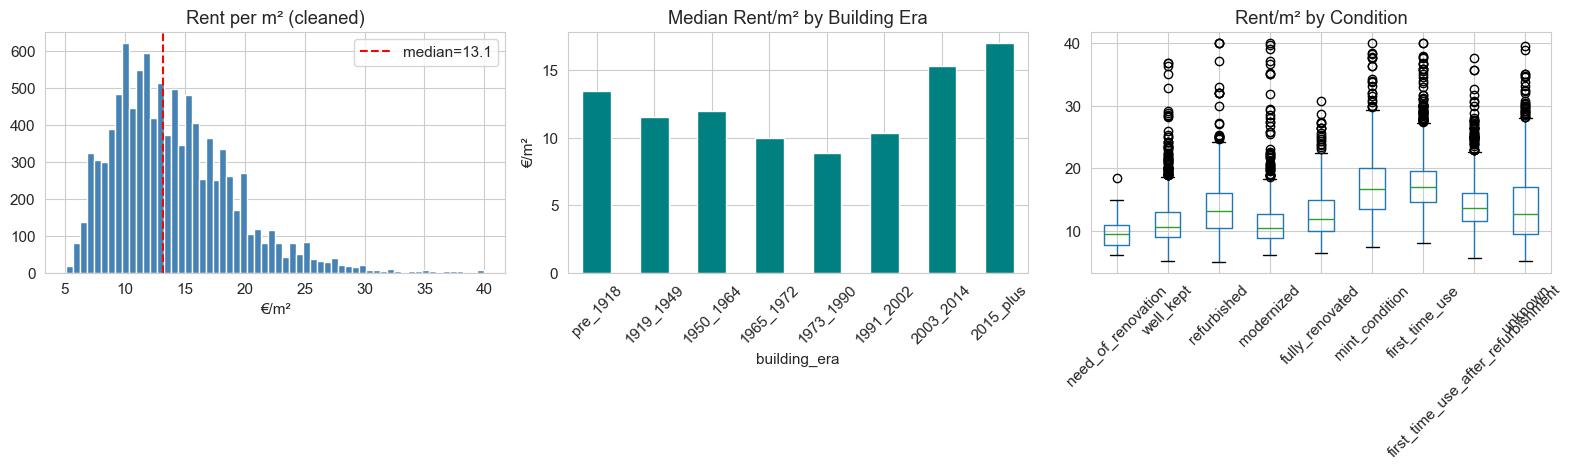

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df["rent_sqm"], bins=60, edgecolor="white", color="steelblue")
axes[0].set_title("Rent per m² (cleaned)")
axes[0].set_xlabel("€/m²")
axes[0].axvline(df["rent_sqm"].median(), color="red", ls="--",
                label=f'median={df["rent_sqm"].median():.1f}')
axes[0].legend()

# Rent by building era
era_order = ["pre_1918", "1919_1949", "1950_1964", "1965_1972",
             "1973_1990", "1991_2002", "2003_2014", "2015_plus", "unknown"]
era_data = df[df["building_era"] != "unknown"]
era_medians = era_data.groupby("building_era")["rent_sqm"].median().reindex(era_order[:-1])
era_medians.plot.bar(ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("Median Rent/m² by Building Era")
axes[1].set_ylabel("€/m²")
axes[1].tick_params(axis="x", rotation=45)

# Amenity premium
for amenity in ["balcony", "hasKitchen", "lift"]:
    has = df[df[amenity] == True]["rent_sqm"].median()
    no = df[df[amenity] == False]["rent_sqm"].median()
    print(f"{amenity}: +{has - no:.2f} €/m² premium ({has:.1f} vs {no:.1f})")

# Boxplot: rent by condition
cond_order = ["need_of_renovation", "well_kept", "refurbished", "modernized",
              "fully_renovated", "mint_condition", "first_time_use",
              "first_time_use_after_refurbishment", "unknown"]
plot_data = df[df["condition"].isin(cond_order)]
plot_data["condition"] = pd.Categorical(plot_data["condition"], categories=cond_order, ordered=True)
plot_data.boxplot(column="rent_sqm", by="condition", ax=axes[2], vert=True)
axes[2].set_title("Rent/m² by Condition")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=45)
fig.suptitle("")

plt.tight_layout()
plt.show()

## 8. Correlation Matrix

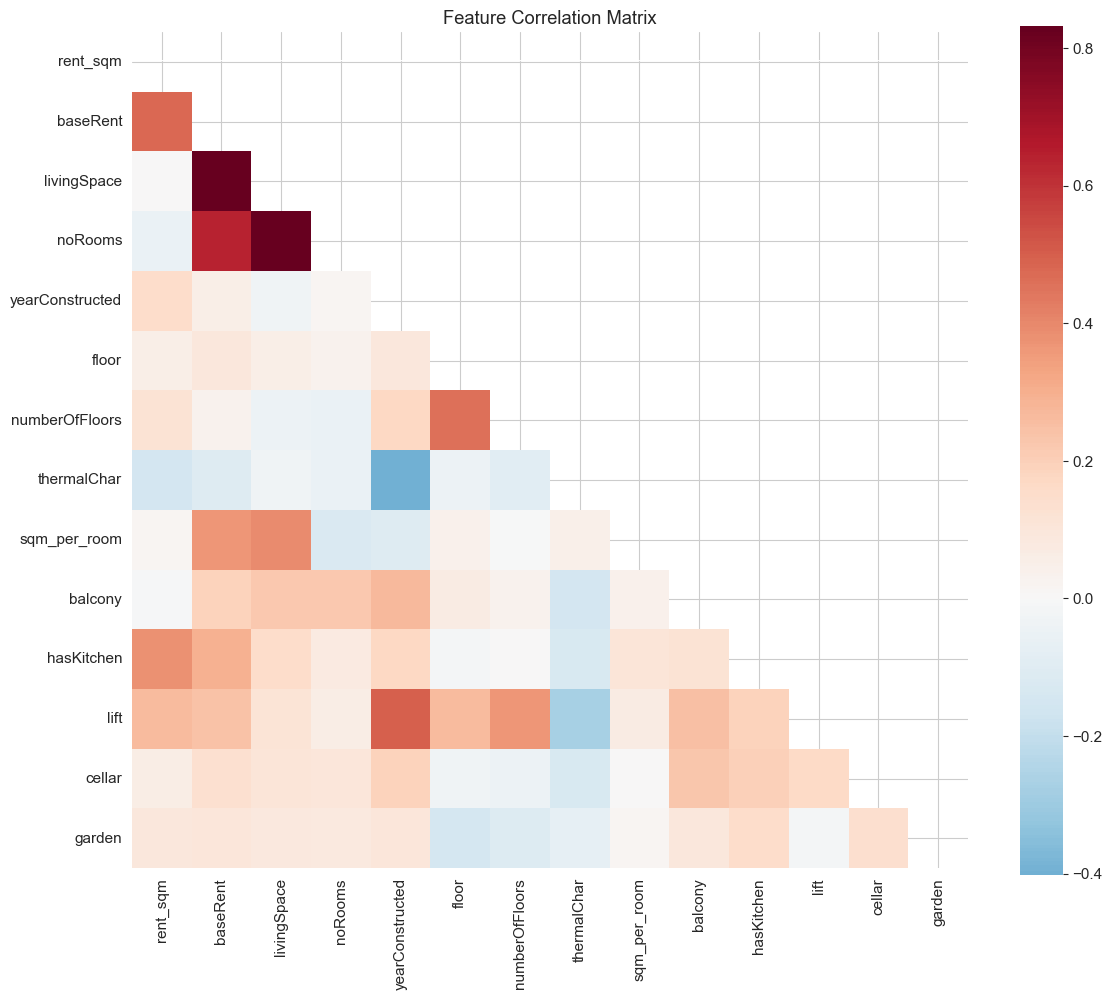

In [12]:
corr_cols = ["rent_sqm", "baseRent", "livingSpace", "noRooms", "yearConstructed",
             "floor", "numberOfFloors", "thermalChar", "sqm_per_room",
             "balcony", "hasKitchen", "lift", "cellar", "garden"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 9. Export Clean Dataset

In [13]:
# Final column selection for the clean dataset
export_cols = [
    # IDs & meta
    "scoutId", "date",
    # Target variables
    "baseRent", "totalRent", "serviceCharge", "rent_sqm",
    # Numeric features
    "livingSpace", "noRooms", "yearConstructed", "floor", "numberOfFloors",
    "thermalChar", "sqm_per_room",
    # Binary features
    "balcony", "hasKitchen", "lift", "cellar", "garden", "newlyConst",
    # Categorical features
    "condition", "interiorQual", "typeOfFlat", "heatingType",
    "building_era",
    # Location
    "bezirk", "neighborhood", "plz",
]

out = df[export_cols].copy()

# Final dtypes
out["plz"] = out["plz"].astype(str)
out["scoutId"] = out["scoutId"].astype(str)

out.to_parquet("../data/processed/listings_clean.parquet", index=False)

print(f"Exported: {len(out):,} rows × {len(out.columns)} columns")
print(f"File: data/processed/listings_clean.parquet")
print(f"\nTarget stats (rent_sqm):")
print(out["rent_sqm"].describe().to_string())
print(f"\nColumns: {list(out.columns)}")

Exported: 10,275 rows × 27 columns
File: data/processed/listings_clean.parquet

Target stats (rent_sqm):
count    10275.000000
mean        14.055061
std          5.099333
min          5.100200
25%         10.227177
50%         13.150000
75%         17.000000
max         40.000000

Columns: ['scoutId', 'date', 'baseRent', 'totalRent', 'serviceCharge', 'rent_sqm', 'livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors', 'thermalChar', 'sqm_per_room', 'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst', 'condition', 'interiorQual', 'typeOfFlat', 'heatingType', 'building_era', 'bezirk', 'neighborhood', 'plz']


In [14]:
# Quick sanity check: read back and verify
check = pd.read_parquet("../data/processed/listings_clean.parquet")
print(f"Read back: {check.shape}")
print(f"Dtypes:\n{check.dtypes.to_string()}")

Read back: (10275, 27)
Dtypes:
scoutId                str
date                   str
baseRent           float64
totalRent          float64
serviceCharge      float64
rent_sqm           float64
livingSpace        float64
noRooms            float64
yearConstructed    float64
floor              float64
numberOfFloors     float64
thermalChar        float64
sqm_per_room       float64
balcony               bool
hasKitchen            bool
lift                  bool
cellar                bool
garden                bool
newlyConst            bool
condition              str
interiorQual           str
typeOfFlat             str
heatingType            str
building_era           str
bezirk                 str
neighborhood           str
plz                    str
